# 09 — Final Strategy vs BIST100

Bu notebook final Robot stratejisini aynı tarih aralıklarında BIST100
(`XU100.IS`) ile karşılaştırır.

Üç seri kullanılır:

- **Final Strategy:** Komisyon ve slippage dahil Robot portföyü
- **BIST100 Gross:** Endeks kapanışının 500.000 TL'ye normalize edilmiş hali
- **BIST100 Net:** İlk açılışta alım ve son kapanışta satış; aynı komisyon ve
  slippage varsayımları uygulanır

Karşılaştırma dönemleri:

- Development: 2018–2022
- Validation: 2023–2024
- Holdout: 2025–son veri
- Full: 2018–son veri


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.features import add_indicators
from src.signals import build_market_regime
from src.experiments import evaluate_strategy
from src.metrics import portfolio_metrics
from src.presets import (
    FINAL_STRATEGY_CONFIG,
    FINAL_PORTFOLIO_CONFIG,
)
from src.benchmark import (
    build_benchmark_equity,
    align_equity_curves,
    active_performance_metrics,
    drawdown_series,
    calendar_return_table,
)


c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Verileri yükle ve final stratejiyi hazırla


In [2]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(market_features)

LAST_DATE = min(
    stock_features["Date"].max(),
    market_prices["Date"].max(),
).strftime("%Y-%m-%d")

PERIODS = {
    "Development": ("2018-01-01", "2022-12-31"),
    "Validation": ("2023-01-01", "2024-12-31"),
    "Holdout": ("2025-01-01", LAST_DATE),
    "Full": ("2018-01-01", LAST_DATE),
}

print("Son ortak veri tarihi:", LAST_DATE)
print("Final strateji:", FINAL_STRATEGY_CONFIG)
print("Final portföy:", FINAL_PORTFOLIO_CONFIG)


Son ortak veri tarihi: 2026-07-23
Final strateji: StrategyConfig(buy_score=11, watch_score=8, market_score=2, close_above_ema200_score=2, ema50_above_ema200_score=2, close_above_ema20_score=1, rsi_score=1, macd_score=1, adx_score=1, volume_score=2, breakout_score=2, minimum_rsi=50.0, minimum_adx=20.0, volume_multiplier=1.3, initial_stop_atr=1.5, trailing_stop_atr=2.5, trailing_activation_return=0.06)
Final portföy: PortfolioConfig(initial_capital=500000.0, risk_per_trade=0.0075, max_positions=6, commission_rate=0.002, slippage_rate=0.002, minimum_valid_return=-0.8, maximum_valid_return=5.0, max_position_fraction=0.2)


## 2. Strateji ve BIST100 performanslarını dönem bazında hesapla

BIST100 Gross standart endeks karşılaştırmasıdır. BIST100 Net ise tek seferlik
alım-satım maliyetini de içerir.


In [3]:
period_records = []
active_records = []
stored_outputs = {}

empty_trades = pd.DataFrame(columns=["Return"])

for period_name, (start, end) in PERIODS.items():
    (
        strategy_raw_metrics,
        strategy_equity,
        strategy_trades,
    ) = evaluate_strategy(
        stock_features=stock_features,
        market_regime=market_regime,
        strategy_config=FINAL_STRATEGY_CONFIG,
        portfolio_config=FINAL_PORTFOLIO_CONFIG,
        start=start,
        end=end,
    )

    benchmark_gross = build_benchmark_equity(
        market_prices=market_prices,
        comparison_dates=strategy_equity["Date"],
        initial_capital=(
            FINAL_PORTFOLIO_CONFIG.initial_capital
        ),
        include_costs=False,
        benchmark_name="BIST100",
    )

    benchmark_net = build_benchmark_equity(
        market_prices=market_prices,
        comparison_dates=strategy_equity["Date"],
        initial_capital=(
            FINAL_PORTFOLIO_CONFIG.initial_capital
        ),
        commission_rate=(
            FINAL_PORTFOLIO_CONFIG.commission_rate
        ),
        slippage_rate=(
            FINAL_PORTFOLIO_CONFIG.slippage_rate
        ),
        include_costs=True,
        benchmark_name="BIST100",
    )

    common_dates = set(benchmark_gross["Date"])

    strategy_aligned = (
        strategy_equity.loc[
            strategy_equity["Date"].isin(common_dates)
        ]
        .sort_values("Date")
        .reset_index(drop=True)
    )

    strategy_metrics = portfolio_metrics(
        strategy_aligned,
        strategy_trades,
    )
    gross_metrics = portfolio_metrics(
        benchmark_gross,
        empty_trades,
    )
    net_metrics = portfolio_metrics(
        benchmark_net,
        empty_trades,
    )

    metric_map = {
        "Final Strategy": strategy_metrics,
        "BIST100 Gross": gross_metrics,
        "BIST100 Net": net_metrics,
    }

    for portfolio_name, metrics in metric_map.items():
        period_records.append(
            {
                "Period": period_name,
                "Portfolio": portfolio_name,
                "Start_Date": (
                    strategy_aligned["Date"].min()
                ),
                "End_Date": (
                    strategy_aligned["Date"].max()
                ),
                "Start_Value_TL": metrics["Start_Value"],
                "End_Value_TL": metrics["End_Value"],
                "Total_Return_%": metrics[
                    "Total_Return_%"
                ],
                "CAGR_%": metrics["CAGR_%"],
                "Max_Drawdown_%": metrics[
                    "Max_Drawdown_%"
                ],
                "Sharpe": metrics["Sharpe"],
                "Sortino": metrics["Sortino"],
                "Calmar": metrics["Calmar"],
                "Profit_Factor": (
                    metrics["Profit_Factor"]
                    if portfolio_name == "Final Strategy"
                    else np.nan
                ),
                "Win_Rate_%": (
                    metrics["Win_Rate_%"]
                    if portfolio_name == "Final Strategy"
                    else np.nan
                ),
                "Trade_Count": (
                    metrics["Trade_Count"]
                    if portfolio_name == "Final Strategy"
                    else np.nan
                ),
                "Exposure_%": metrics["Exposure_%"],
            }
        )

    aligned_active = align_equity_curves(
        strategy_aligned,
        benchmark_gross,
    )

    active_metrics = active_performance_metrics(
        aligned_active
    )

    active_metrics.update(
        {
            "Period": period_name,
            "Strategy_CAGR_%": strategy_metrics["CAGR_%"],
            "BIST100_CAGR_%": gross_metrics["CAGR_%"],
            "Excess_CAGR_pp": (
                strategy_metrics["CAGR_%"]
                - gross_metrics["CAGR_%"]
            ),
            "Strategy_Max_DD_%": strategy_metrics[
                "Max_Drawdown_%"
            ],
            "BIST100_Max_DD_%": gross_metrics[
                "Max_Drawdown_%"
            ],
            "Drawdown_Difference_pp": (
                strategy_metrics["Max_Drawdown_%"]
                - gross_metrics["Max_Drawdown_%"]
            ),
        }
    )

    active_records.append(active_metrics)

    stored_outputs[period_name] = {
        "strategy_equity": strategy_aligned,
        "strategy_trades": strategy_trades,
        "benchmark_gross": benchmark_gross,
        "benchmark_net": benchmark_net,
        "aligned_active": aligned_active,
    }

comparison_table = pd.DataFrame(period_records)
active_table = pd.DataFrame(active_records)

display(
    comparison_table.sort_values(
        ["Period", "Portfolio"]
    )
)

print("AKTİF PERFORMANS")
display(
    active_table.sort_values("Period")
)


,Period,Portfolio,Start_Date,End_Date,Start_Value_TL,End_Value_TL,Total_Return_%,CAGR_%,Max_Drawdown_%,Sharpe,Sortino,Calmar,Profit_Factor,Win_Rate_%,Trade_Count,Exposure_%
1,Development,BIST100 Gross,2018-10-18,2022-12-30,500000.000000,2.826565e+06,465.312902,51.050526,-31.815427,1.765808,2.064752,1.604584,NaN,NaN,NaN,100.000000
2,Development,BIST100 Net,2018-10-18,2022-12-30,490292.915495,2.760142e+06,462.957657,50.900445,-31.810211,1.762117,2.060366,1.600129,NaN,NaN,NaN,99.904671
0,Development,Final Strategy,2018-10-18,2022-12-30,500000.000000,3.517044e+06,603.408770,59.119246,-21.593640,2.387415,3.290275,2.737808,2.494549,37.967914,374.0,96.091516
10,Full,BIST100 Gross,2018-10-18,2026-07-23,500000.000000,7.222780e+06,1344.555940,41.063778,-31.815427,1.432141,1.869862,1.290688,NaN,NaN,NaN,100.000000
11,Full,BIST100 Net,2018-10-18,2026-07-23,490292.915495,7.052889e+06,1338.505204,40.987514,-31.810211,1.430130,1.867651,1.288502,NaN,NaN,NaN,99.948213
9,Full,Final Strategy,2018-10-18,2026-07-23,500000.000000,1.331542e+07,2563.084757,52.630340,-25.524609,2.168288,3.075593,2.061945,2.171562,34.829932,735.0,97.721388
7,Holdout,BIST100 Gross,2025-01-02,2026-07-23,500000.000000,7.066234e+05,41.324676,24.958964,-17.061152,1.037176,1.467252,1.462912,NaN,NaN,NaN,100.000000
8,Holdout,BIST100 Net,2025-01-02,2026-07-23,503186.401355,7.061963e+05,40.344876,24.400196,-16.901688,1.025630,1.452356,1.443654,NaN,NaN,NaN,99.741602
6,Holdout,Final Strategy,2025-01-02,2026-07-23,500000.000000,9.877387e+05,97.547740,55.047940,-10.932331,2.273629,3.360454,5.035334,2.054227,31.325301,166.0,99.483204
4,Validation,BIST100 Gross,2023-01-02,2024-12-31,500000.000000,8.682588e+05,73.651768,31.851838,-22.860878,1.058931,1.610602,1.393290,NaN,NaN,NaN,100.000000


AKTİF PERFORMANS


,Alpha_Annual_%,Beta,Correlation,Tracking_Error_%,Information_Ratio,Upside_Capture_%,Downside_Capture_%,Active_Total_Return_pp,Strategy_Annual_Volatility_%,Benchmark_Annual_Volatility_%,Period,Strategy_CAGR_%,BIST100_CAGR_%,Excess_CAGR_pp,Strategy_Max_DD_%,BIST100_Max_DD_%,Drawdown_Difference_pp
0,28.503861,0.457342,0.566562,21.855104,0.187980,55.187366,35.058246,138.095869,20.551096,25.458977,Development,59.119246,51.050526,8.068720,-21.593640,-31.815427,10.221787
3,28.340553,0.433686,0.561542,22.970312,0.283950,52.825818,34.369184,1218.528817,20.776293,26.901385,Full,52.630340,41.063778,11.566561,-25.524609,-31.815427,6.290818
2,36.242605,0.402943,0.486483,23.204983,0.901779,53.640676,27.924213,56.223064,20.486919,24.734370,Holdout,55.047940,24.958964,30.088976,-10.932331,-17.061152,6.128821
1,19.963617,0.412943,0.609638,24.805576,0.023409,47.700291,37.031872,11.249072,21.119841,31.179723,Validation,36.064262,31.851838,4.212424,-23.126455,-22.860878,-0.265577


## 3. Dönem bazında özet görünüm


In [4]:
summary_view = comparison_table.pivot_table(
    index="Period",
    columns="Portfolio",
    values=[
        "End_Value_TL",
        "Total_Return_%",
        "CAGR_%",
        "Max_Drawdown_%",
        "Sharpe",
        "Calmar",
    ],
    aggfunc="first",
)

display(summary_view)


CAGR_%                                   Calmar  \
Portfolio   BIST100 Gross BIST100 Net Final Strategy BIST100 Gross   
Period                                                               
Development     51.050526   50.900445      59.119246      1.604584   
Full            41.063778   40.987514      52.630340      1.290688   
Holdout         24.958964   24.400196      55.047940      1.462912   
Validation      31.851838   31.453998      36.064262      1.393290   

                                        End_Value_TL                \
Portfolio   BIST100 Net Final Strategy BIST100 Gross   BIST100 Net   
Period                                                               
Development    1.600129       2.737808  2.826565e+06  2.760142e+06   
Full           1.288502       2.061945  7.222780e+06  7.052889e+06   
Holdout        1.443654       5.035334  7.066234e+05  7.061963e+05   
Validation     1.379251       1.559438  8.682588e+05  8.738533e+05   

                           Max_Drawdown_%                             \
Portfolio   Final Strategy  BIST100 Gross BIST100 Net Final Strategy   
Period                                                                 
Development   3.517044e+06     -31.815427  -31.810211     -21.593640   
Full          1.331542e+07     -31.815427  -31.810211     -25.524609   
Holdout       9.877387e+05     -17.061152  -16.901688     -10.932331   
Validation    9.245042e+05     -22.860878  -22.805131     -23.126455   

                   Sharpe                            Total_Return_%  \
Portfolio   BIST100 Gross BIST100 Net Final Strategy  BIST100 Gross   
Period                                                                
Development      1.765808    1.762117       2.387415     465.312902   
Full             1.432141    1.430130       2.168288    1344.555940   
Holdout          1.037176    1.025630       2.273629      41.324676   
Validation       1.058931    1.052103       1.590818      73.651768   

                                         
Portfolio    BIST100 Net Final Strategy  
Period                                   
Development   462.957657     603.408770  
Full         1338.505204    2563.084757  
Holdout        40.344876      97.547740  
Validation     72.607563      84.900841

## 4. Tam dönem: 500.000 TL'nin gelişimi


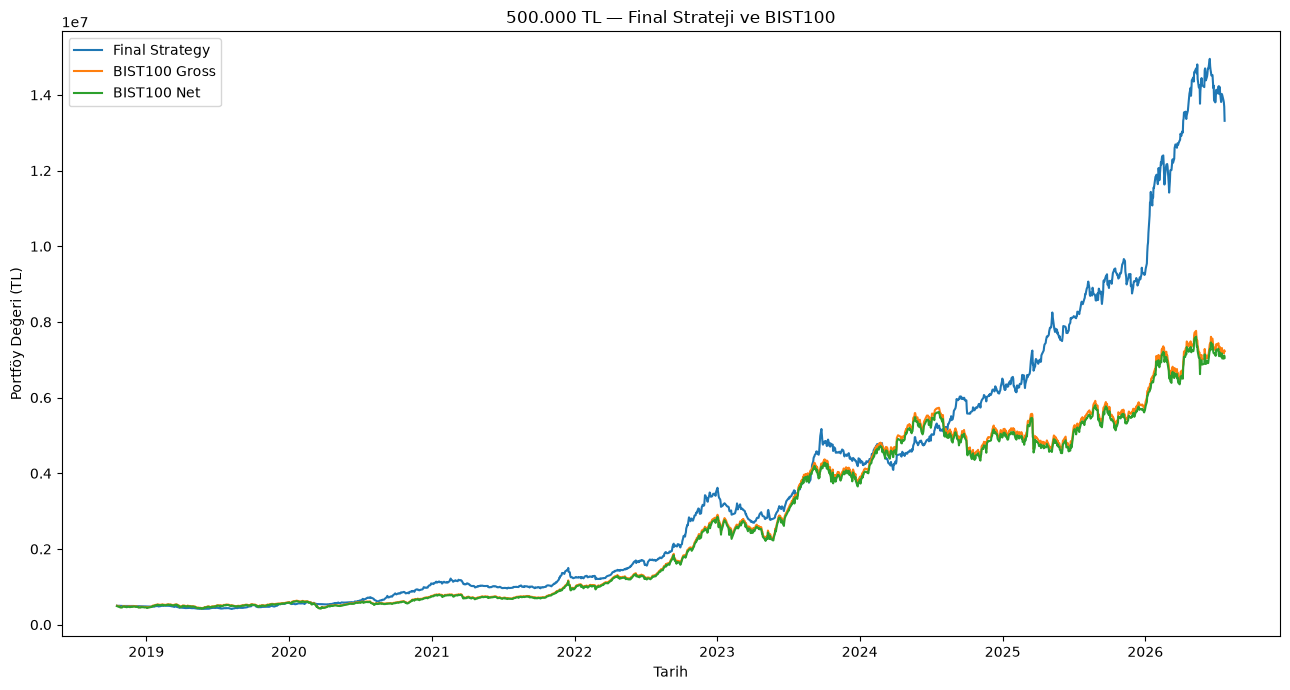

In [5]:
full_strategy = stored_outputs["Full"][
    "strategy_equity"
]
full_gross = stored_outputs["Full"][
    "benchmark_gross"
]
full_net = stored_outputs["Full"][
    "benchmark_net"
]

growth_chart = (
    full_strategy[["Date", "Equity"]]
    .rename(
        columns={"Equity": "Final Strategy"}
    )
    .merge(
        full_gross[["Date", "Equity"]].rename(
            columns={"Equity": "BIST100 Gross"}
        ),
        on="Date",
        how="inner",
    )
    .merge(
        full_net[["Date", "Equity"]].rename(
            columns={"Equity": "BIST100 Net"}
        ),
        on="Date",
        how="inner",
    )
)

growth_chart = growth_chart.set_index("Date")

plt.figure(figsize=(13, 7))
plt.plot(
    growth_chart.index,
    growth_chart["Final Strategy"],
    label="Final Strategy",
)
plt.plot(
    growth_chart.index,
    growth_chart["BIST100 Gross"],
    label="BIST100 Gross",
)
plt.plot(
    growth_chart.index,
    growth_chart["BIST100 Net"],
    label="BIST100 Net",
)
plt.title("500.000 TL — Final Strateji ve BIST100")
plt.xlabel("Tarih")
plt.ylabel("Portföy Değeri (TL)")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Tam dönem drawdown karşılaştırması


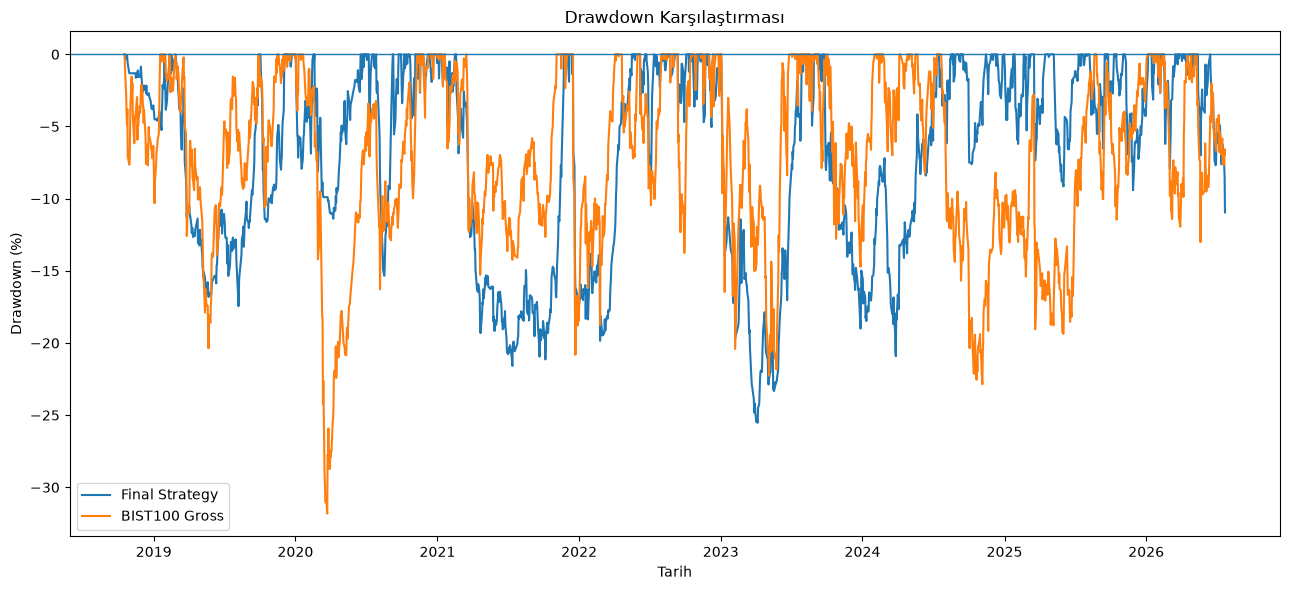

In [6]:
strategy_dd = drawdown_series(
    full_strategy
).rename(
    columns={"Drawdown_%": "Final Strategy"}
)

bist100_dd = drawdown_series(
    full_gross
).rename(
    columns={"Drawdown_%": "BIST100 Gross"}
)

drawdown_chart = strategy_dd.merge(
    bist100_dd,
    on="Date",
    how="inner",
).set_index("Date")

plt.figure(figsize=(13, 6))
plt.plot(
    drawdown_chart.index,
    drawdown_chart["Final Strategy"],
    label="Final Strategy",
)
plt.plot(
    drawdown_chart.index,
    drawdown_chart["BIST100 Gross"],
    label="BIST100 Gross",
)
plt.axhline(0, linewidth=1)
plt.title("Drawdown Karşılaştırması")
plt.xlabel("Tarih")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Takvim yılı getirileri


In [7]:
yearly_returns = calendar_return_table(
    {
        "Final Strategy": full_strategy,
        "BIST100 Gross": full_gross,
    },
    frequency="YE",
)

yearly_returns["Year"] = (
    yearly_returns["Date"].dt.year
)

yearly_table = yearly_returns.pivot_table(
    index="Year",
    columns="Portfolio",
    values="Return_%",
    aggfunc="first",
).reset_index()

yearly_table["Excess_Return_pp"] = (
    yearly_table["Final Strategy"]
    - yearly_table["BIST100 Gross"]
)

display(yearly_table)


Portfolio,Year,BIST100 Gross,Final Strategy,Excess_Return_pp
0,2018,-6.345037,-3.538514,2.806523
1,2019,25.369086,20.594143,-4.774944
2,2020,29.053967,86.281311,57.227344
3,2021,25.800769,13.962246,-11.838523
4,2022,196.560282,185.588896,-10.971386
5,2023,35.595007,24.671885,-10.923122
6,2024,31.597543,47.935397,16.337854
7,2025,14.556179,42.236339,27.680160
8,2026,25.007328,43.940177,18.932849


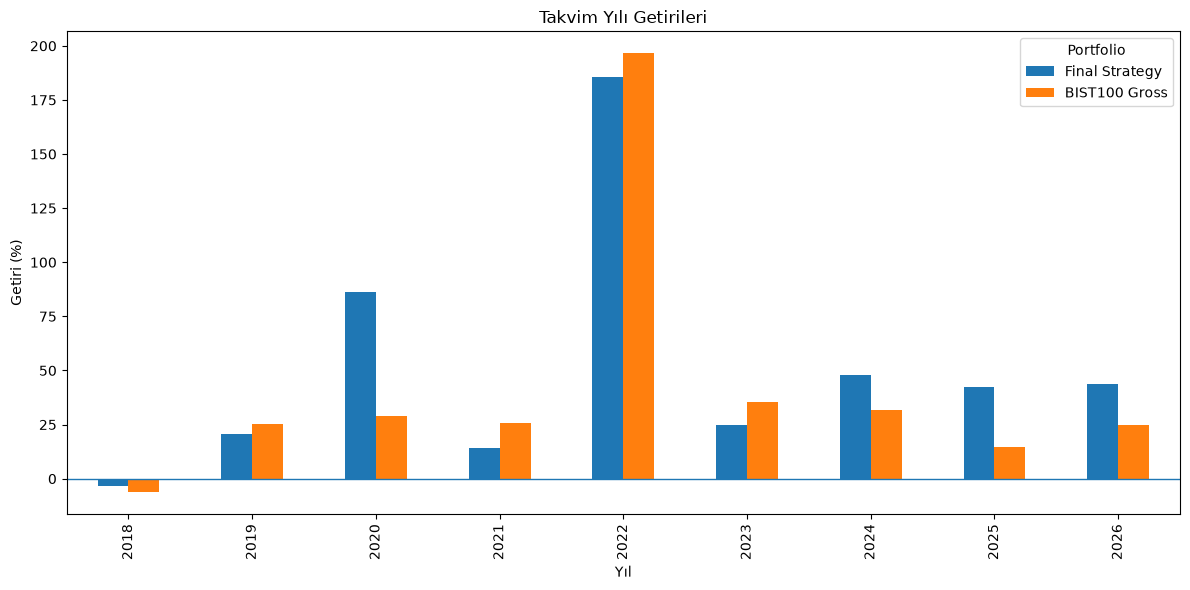

In [8]:
yearly_plot = yearly_table.set_index("Year")[
    ["Final Strategy", "BIST100 Gross"]
]

plt.figure(figsize=(12, 6))
yearly_plot.plot(
    kind="bar",
    ax=plt.gca(),
)
plt.axhline(0, linewidth=1)
plt.title("Takvim Yılı Getirileri")
plt.xlabel("Yıl")
plt.ylabel("Getiri (%)")
plt.tight_layout()
plt.show()


## 7. Aylık başarı oranı ve rolling 12 aylık getiri


In [9]:
monthly_returns = calendar_return_table(
    {
        "Final Strategy": full_strategy,
        "BIST100 Gross": full_gross,
    },
    frequency="ME",
)

monthly_pivot = monthly_returns.pivot_table(
    index="Date",
    columns="Portfolio",
    values="Return_%",
    aggfunc="first",
).dropna()

monthly_pivot["Excess_Return_pp"] = (
    monthly_pivot["Final Strategy"]
    - monthly_pivot["BIST100 Gross"]
)

monthly_summary = pd.DataFrame(
    [
        {
            "Compared_Months": len(monthly_pivot),
            "Strategy_Beat_BIST100_Months": int(
                monthly_pivot[
                    "Excess_Return_pp"
                ].gt(0).sum()
            ),
            "Monthly_Hit_Rate_%": (
                monthly_pivot[
                    "Excess_Return_pp"
                ].gt(0).mean()
                * 100
            ),
            "Average_Monthly_Excess_pp": (
                monthly_pivot[
                    "Excess_Return_pp"
                ].mean()
            ),
            "Median_Monthly_Excess_pp": (
                monthly_pivot[
                    "Excess_Return_pp"
                ].median()
            ),
        }
    ]
)

display(monthly_summary)


,Compared_Months,Strategy_Beat_BIST100_Months,Monthly_Hit_Rate_%,Average_Monthly_Excess_pp,Median_Monthly_Excess_pp
0,94,47,50.0,0.671504,0.036337


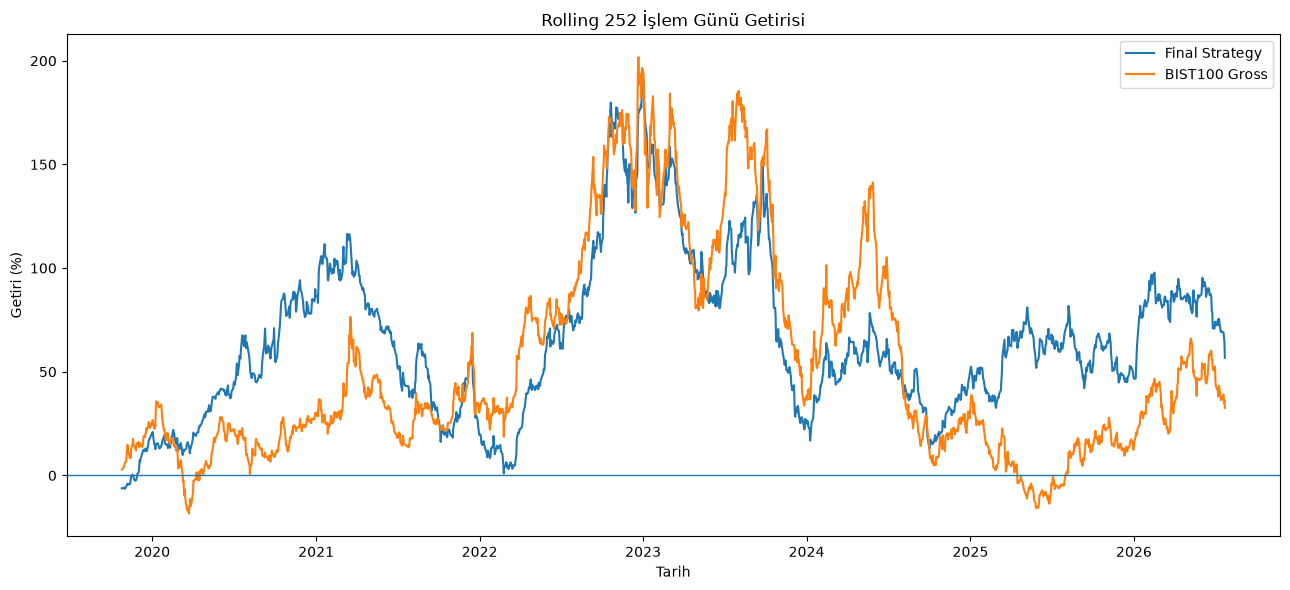

In [10]:
rolling_returns = growth_chart.pct_change(
    252,
    fill_method=None,
) * 100

plt.figure(figsize=(13, 6))
plt.plot(
    rolling_returns.index,
    rolling_returns["Final Strategy"],
    label="Final Strategy",
)
plt.plot(
    rolling_returns.index,
    rolling_returns["BIST100 Gross"],
    label="BIST100 Gross",
)
plt.axhline(0, linewidth=1)
plt.title("Rolling 252 İşlem Günü Getirisi")
plt.xlabel("Tarih")
plt.ylabel("Getiri (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Sonuçları kaydet

`Final Strategy` sonuçları komisyon ve slippage içerir. `BIST100 Gross`
standart fiyat endeksi karşılaştırmasıdır. `BIST100 Net` aynı maliyetlerle
tek seferlik al-tut uygulamasını gösterir.


In [11]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_table.to_csv(
    RESULTS_DIR
    / "final_strategy_vs_bist100_periods.csv",
    index=False,
)

active_table.to_csv(
    RESULTS_DIR
    / "final_strategy_vs_bist100_active_metrics.csv",
    index=False,
)

yearly_table.to_csv(
    RESULTS_DIR
    / "final_strategy_vs_bist100_yearly.csv",
    index=False,
)

monthly_pivot.reset_index().to_csv(
    RESULTS_DIR
    / "final_strategy_vs_bist100_monthly.csv",
    index=False,
)

monthly_summary.to_csv(
    RESULTS_DIR
    / "final_strategy_vs_bist100_monthly_summary.csv",
    index=False,
)

full_strategy.to_parquet(
    RESULTS_DIR
    / "final_strategy_equity.parquet",
    index=False,
)

stored_outputs["Full"][
    "strategy_trades"
].to_csv(
    RESULTS_DIR
    / "final_strategy_trades.csv",
    index=False,
)

full_gross.to_parquet(
    RESULTS_DIR
    / "bist100_gross_benchmark_equity.parquet",
    index=False,
)

full_net.to_parquet(
    RESULTS_DIR
    / "bist100_net_benchmark_equity.parquet",
    index=False,
)

print("BIST100 karşılaştırma sonuçları kaydedildi.")


BIST100 karşılaştırma sonuçları kaydedildi.


## Yorumlama notları

- **Excess CAGR pozitifse:** Strateji yıllıklandırılmış olarak BIST100'ü geçmiş.
- **Alpha pozitifse:** BIST100 günlük hareketleriyle açıklanamayan ek getiri var.
- **Beta 1'in altındaysa:** Strateji BIST100'e göre daha düşük piyasa duyarlılığı taşıyor.
- **Downside Capture %100'ün altındaysa:** BIST100 düşüş günlerinin daha küçük bir kısmı portföye yansımış.
- **Information Ratio pozitif ve yüksekse:** Aktif getiri daha tutarlı üretilmiş.

Sınırlamalar:

1. BIST100 (`XU100.IS`) bir fiyat endeksidir; temettülerin tamamını temsil eden
   toplam getiri endeksi değildir.
2. Hisse fiyatlarında `auto_adjust=True` kullanılması temettü ve bölünme
   düzeltmelerini içerebilir; bu nedenle kıyaslama tamamen bire bir değildir.
3. Güncel BIST100 listesini geçmişe uygulamak survivorship bias oluşturur.
4. Development, validation ve holdout sonuçları artık görülmüştür. Gerçek
   yeni out-of-sample değerlendirme paper trading ile yapılacaktır.
